In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, skew, mannwhitneyu, shapiro, weibull_min, probplot
import statsmodels.stats.power as smp
import statsmodels.api as sm
import scipy
# from lifelines import WeibullFitter

In [2]:
# Load the data.
df = pd.read_excel('Time_for_Bac_Fix_MutRate_Comparison.xlsx', sheet_name='All Time Distributions')
df.head()

,SOS,Spontaneous
0,19232,26374
1,11287,86400
2,21931,53988
3,19650,47586
4,26696,86400


### Data Cleaning

In [3]:
# Removing Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Remove outliers
df_cleaned = df.copy()
df_cleaned['SOS'] = remove_outliers(df, 'SOS')['SOS']
df_cleaned['Spontaneous'] = remove_outliers(df, 'Spontaneous')['Spontaneous']
df_cleaned.describe()

,SOS,Spontaneous
count,94.000000,100.000000
mean,21746.510638,61734.430000
std,3695.819212,23808.213714
min,12174.000000,20177.000000
25%,19232.000000,46438.000000
50%,21377.000000,53988.000000
75%,24377.750000,86400.000000
max,30816.000000,86400.000000


- SOS is the mutation rate with the SOS response.
- Spontaneous is a mutation rate without the SOS response, (100x slower).

### Descriptive Statistics

Spontaneous Mutation Fitted Weibull PDF Parameters
Shape (k): 2.97
Location (loc): 0
Scale (λ): 69444.47 s
k = 2.97.  A value of k > 1 indicates the indicates that the event becomes more likely as time goes on.
Estimated time until event (50th percentile): 61379.63 seconds = 17.05 hours


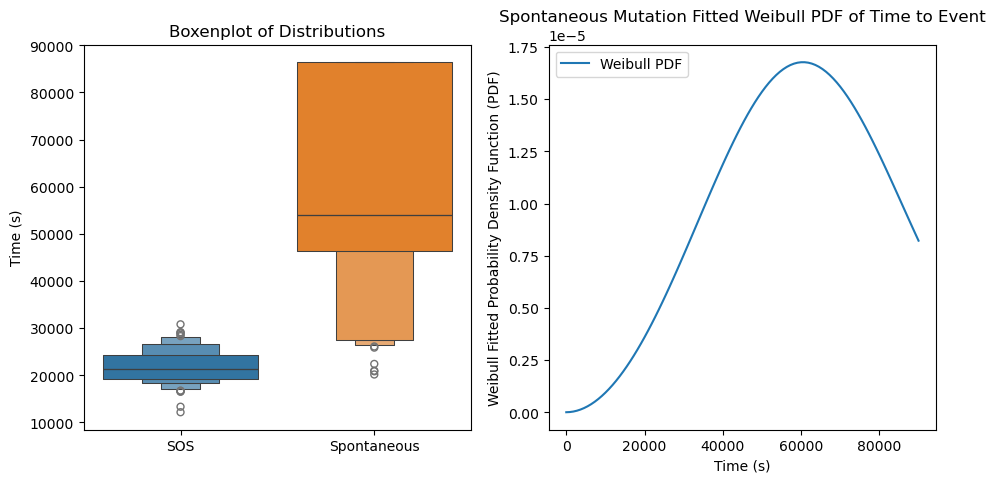

In [28]:
times = df['Spontaneous'].dropna()

# Censoring indicator (1 = event occurred, 0 = censored)
events = (times != 86400).astype(int)

# Fit Weibull distribution
params = weibull_min.fit(times, floc=0)

# Print the parameters (shape, loc, scale)
# Weibull Parameters:
#    Shape Parameter (k)
#    Location Parameter (loc)
#    Scale Parameter (λ)
print(f"Spontaneous Mutation Fitted Weibull PDF Parameters\nShape (k): {params[0]:.2f}\nLocation (loc): {params[1]}\nScale (λ): {params[2]:.2f} s")
print("k = {:.2f}.  A value of k > 1 indicates the indicates that the event becomes more likely as time goes on.".format(params[0]))

# Estimate the time until event for a given percentile
percentile = 0.5  # Median time to event
time_to_event = weibull_min.ppf(percentile, *params)

print(f"Estimated time until event (50th percentile): {time_to_event:.2f} seconds = {(time_to_event)/3600:.2f} hours")

# Plot the cumulative distribution function (CDF)
x = np.linspace(0, 90000, 100)
den_func = weibull_min.pdf(x, *params)

fig,axs = plt.subplots(1,2, figsize=(11,5))

sns.boxenplot(data=df_cleaned, ax=axs[0])
axs[0].set_title('Boxenplot of Distributions')
axs[0].set_ylabel('Time (s)')

axs[1].plot(x, den_func, label='Weibull PDF')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Weibull Fitted Probability Density Function (PDF)')
axs[1].set_title('Spontaneous Mutation Fitted Weibull PDF of Time to Event')
axs[1].legend()
plt.show()

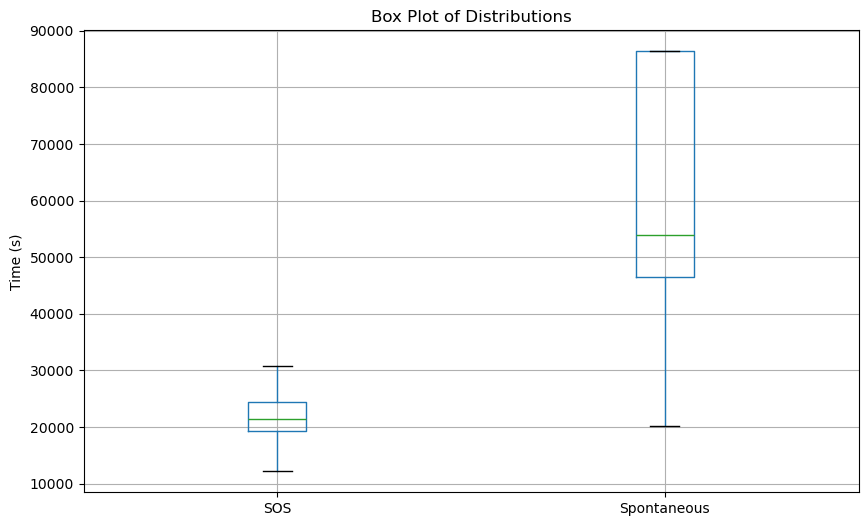

In [5]:
# Visualize the Data
plt.figure(figsize=(10, 6))
df_cleaned.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Time (s)')
plt.show()

### Data Normalization and Histograms

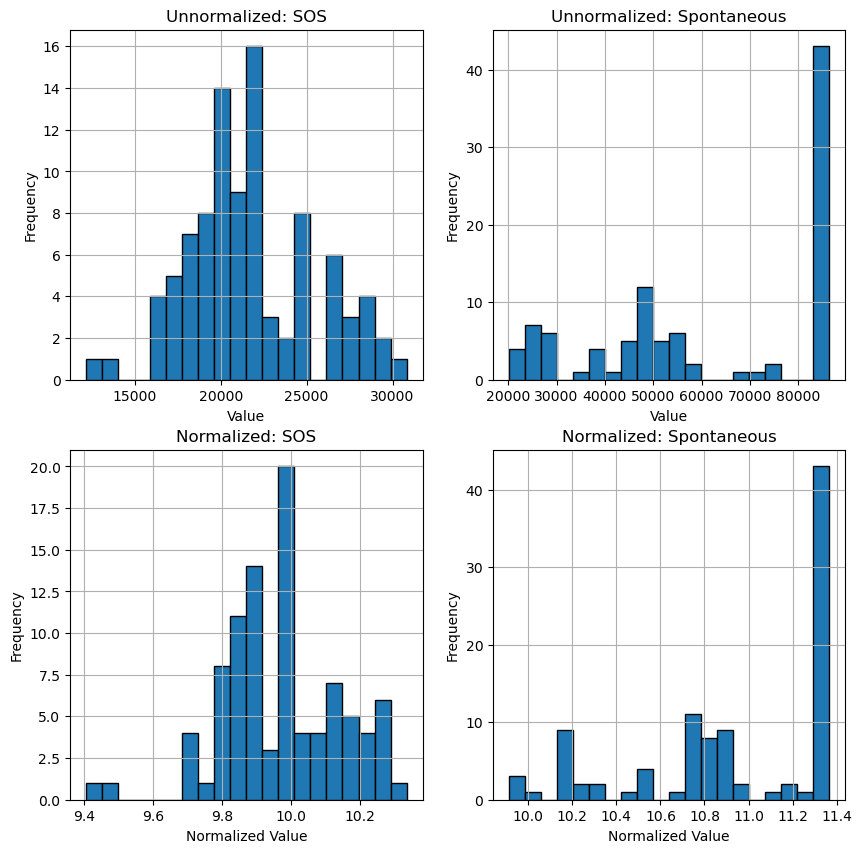

In [149]:
normalized_df_cleaned = df_cleaned.apply(lambda x: np.log(x))

# Number of columns to plot
num_columns = len(df_cleaned.columns)

# Create subplots
fig, axs = plt.subplots(2, num_columns, figsize=(5 * num_columns, 10))

# Ensure axs is 2-dimensional, even if there is only one column
if num_columns == 1:
    axs = np.array([[axs[0]], [axs[1]]])

# Plot histograms for each column in unnormalized data
for i, column in enumerate(df_cleaned.columns):
    df_cleaned[column].hist(ax=axs[0, i], bins=20, edgecolor='k')
    axs[0, i].set_title(f'Unnormalized: {column}')
    axs[0, i].set_xlabel('Value')
    axs[0, i].set_ylabel('Frequency')

# Plot histograms for each column in normalized data
for i, column in enumerate(normalized_df_cleaned.columns):
    normalized_df_cleaned[column].hist(ax=axs[1, i], bins=20, edgecolor='k')
    axs[1, i].set_title(f'Normalized: {column}')
    axs[1, i].set_xlabel('Normalized Value')
    axs[1, i].set_ylabel('Frequency')

### Regression Analysis

In [8]:
# Prepare the combined dataset
df_sos = df_cleaned[['SOS']].rename(columns={'SOS': 'Time'}).assign(Group='SOS')
df_spontaneous = df_cleaned[['Spontaneous']].rename(columns={'Spontaneous': 'Time'}).assign(Group='Spontaneous')
combined_df = pd.concat([df_sos, df_spontaneous], ignore_index=True)
# Then remove NaN values from 'Time'.
combined_df_clean = combined_df.dropna(subset=['Time'])
combined_df_clean

,Time,Group
0,19232.0,SOS
2,21931.0,SOS
3,19650.0,SOS
4,26696.0,SOS
5,17714.0,SOS
...,...,...
195,86400.0,Spontaneous
196,86400.0,Spontaneous
197,46438.0,Spontaneous
198,86400.0,Spontaneous


In [ ]:
# Fit Weibull distribution for each group with cleaned data
sos_times_clean = combined_df_clean[combined_df_clean['Group'] == 'SOS']['Time']
spontaneous_times_clean = combined_df_clean[combined_df_clean['Group'] == 'Spontaneous']['Time']

params_sos_clean = weibull_min.fit(sos_times_clean, floc=0)
params_spontaneous_clean = weibull_min.fit(spontaneous_times_clean, floc=0)

# Print the cleaned parameters
weibull_params_clean = {
    'SOS': {
        'shape': params_sos_clean[0],
        'location': params_sos_clean[1],
        'scale': params_sos_clean[2]
    },
    'Spontaneous': {
        'shape': params_spontaneous_clean[0],
        'location': params_spontaneous_clean[1],
        'scale': params_spontaneous_clean[2]
    }
}

# Prepare the combined cleaned dataset with Weibull-fitted values
combined_df_clean['Shape'] = combined_df_clean['Group'].apply(lambda x: weibull_params_clean[x]['shape'])
combined_df_clean['Scale'] = combined_df_clean['Group'].apply(lambda x: weibull_params_clean[x]['scale'])

# Create a binary variable for the group
combined_df_clean['SOS'] = combined_df_clean['Group'].apply(lambda x: 0 if x == 'Spontaneous' else 1)
combined_df_clean['SOS'] = combined_df_clean['SOS'].astype(float)

In [10]:
# Check the structure of the dataset
combined_df_clean.head()

,Time,Group,Shape,Scale,SOS
0,19232.0,SOS,6.212791,23323.520719,1.0
2,21931.0,SOS,6.212791,23323.520719,1.0
3,19650.0,SOS,6.212791,23323.520719,1.0
4,26696.0,SOS,6.212791,23323.520719,1.0
5,17714.0,SOS,6.212791,23323.520719,1.0


In [12]:
# Replace censored times with the estimated mean time from Weibull distribution
def estimate_weibull_mean(params):
    shape, loc, scale = params
    return scale * scipy.special.gamma(1 + 1/shape)

estimated_mean_spontaneous = estimate_weibull_mean(params_spontaneous_clean)
combined_df_clean_estimate = combined_df_clean.copy()
combined_df_clean_estimate['Time'] = combined_df_clean_estimate['Time'].astype(float)
combined_df_clean_estimate.loc[(combined_df_clean['Group'] == 'Spontaneous') & (combined_df_clean['Time'] == 86400), 'Time'] = estimated_mean_spontaneous

In [163]:
# All the 24h limits have been replaced.
combined_df_clean_estimate[combined_df_clean_estimate['Time']==86400]

,Time,Group,Shape,Scale,SOS


In [164]:
combined_df_clean_estimate['Log_Time'] = combined_df_clean_estimate['Time'].apply(lambda x: np.log(x))
combined_df_clean_estimate

,Time,Group,Shape,Scale,SOS,Log_Time
0,19232.000000,SOS,6.212791,23323.520719,1.0,9.864331
2,21931.000000,SOS,6.212791,23323.520719,1.0,9.995656
3,19650.000000,SOS,6.212791,23323.520719,1.0,9.885833
4,26696.000000,SOS,6.212791,23323.520719,1.0,10.192269
5,17714.000000,SOS,6.212791,23323.520719,1.0,9.782111
...,...,...,...,...,...,...
195,61984.349689,Spontaneous,2.968933,69444.470434,0.0,11.034637
196,61984.349689,Spontaneous,2.968933,69444.470434,0.0,11.034637
197,46438.000000,Spontaneous,2.968933,69444.470434,0.0,10.745873
198,61984.349689,Spontaneous,2.968933,69444.470434,0.0,11.034637


In [170]:
# Define the dependent variable (Time)
y = combined_df_clean_estimate['Log_Time']

# Define the independent variables (Group)
X = combined_df_clean_estimate[['SOS']]

# Add a constant to the independent variables
X = sm.add_constant(X)

# Perform OLS regression
model = sm.OLS(y, X).fit()

# Print the summary of the regression
model_summary = model.summary()
print(model_summary)

                            OLS Regression Results                            
Dep. Variable:               Log_Time   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     456.8
Date:                Wed, 03 Jul 2024   Prob (F-statistic):           1.18e-52
Time:                        14:35:27   Log-Likelihood:                -20.713
No. Observations:                 194   AIC:                             45.43
Df Residuals:                     192   BIC:                             51.96
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.8038      0.027    399.203      0.0

- The adjusted R-squared accounts for 70.3% of the variance in the time to fixation.  Much higher than all the other variables.
- The high F-statistic (456.8), and low p-value (p < 0.0001), indicate that the model is statistically significant.
- The coefficient of -0.8309 indicates that SOS significanly shortens the time until fixation.
- This gives important context to the SOS mutation rates in an evolutionary process, and for its role in accelerated mutation.

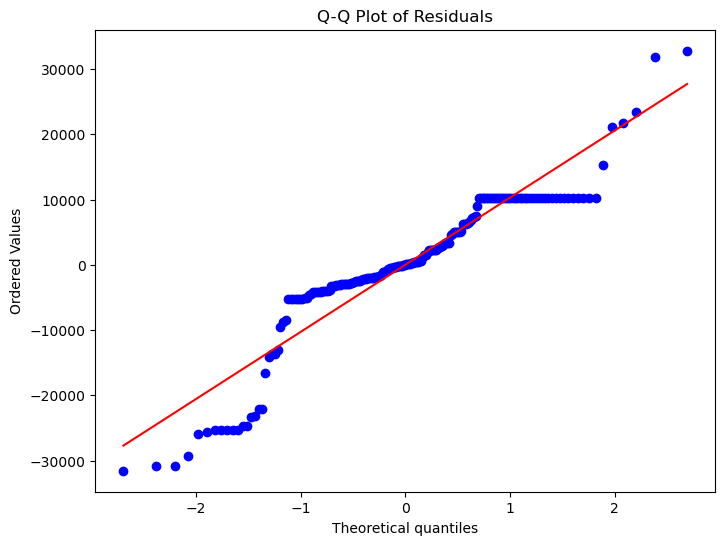

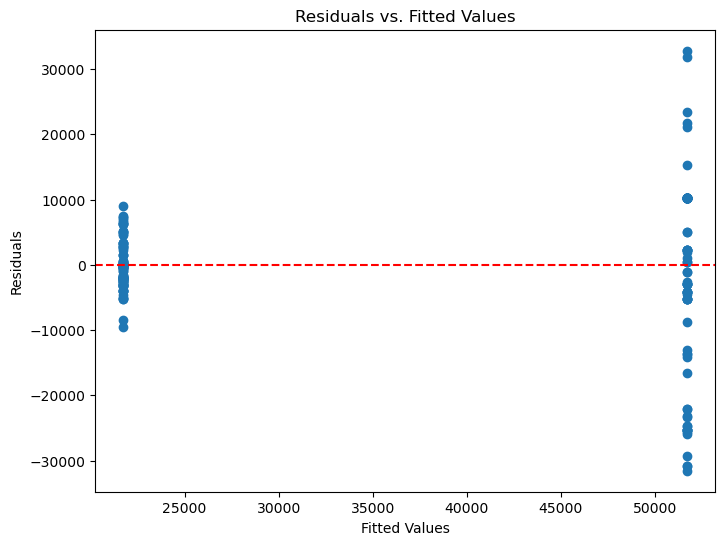

In [169]:
# Residuals
residuals = model.resid

# Q-Q plot
plt.figure(figsize=(8, 6))
probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

# Residuals vs. Fitted values
plt.figure(figsize=(8, 6))
plt.scatter(model.fittedvalues, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values')
plt.show()

In [171]:
combined_df_clean_estimate.to_excel('Spon_SOS_Cleaned_Estimate.xlsx')